# Analyse results from Pypsa-Earth

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Own setting

In [125]:
import os
import sys
import yaml

PARENT = os.path.realpath("../../pypsa-earth") + "/"
config = yaml.safe_load(open(PARENT + "config-2030-NetZero-eia-hydro.yaml"))

# Read config.yaml settings:
name = config["run"]["name"]
simpl = config["scenario"]["simpl"]
# clusters = "10"
clusters = config["scenario"]["clusters"]
ll = config["scenario"]["ll"]
opts = config["scenario"]["opts"]

# Ensure elements are strings and properly joined
simpl_str = "_".join(map(str, simpl))
clusters_str = "_".join(map(str, clusters))
#clusters_str = clusters
ll_str = "_".join(map(str, ll))
opts_str = "_".join(map(str, opts))
export = "1"
geothermal_potential = "3"

## Import packages

In [126]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy

## Path settings

In [127]:
# nc_file_name = f"elec_s{simpl_str}_{clusters_str}_ec_l{ll_str}_{opts_str}-{export}-{geothermal_potential}.nc"
nc_file_name = f"elec_s{simpl_str}_{clusters_str}_ec_l{ll_str}_{opts_str}.nc"
scenario_name = name 
scenario_subpath = scenario_name + "/" if scenario_name else ""

# Network file
results_path = PARENT + f"results/{scenario_subpath}networks/{nc_file_name}"
network_path = PARENT + f"networks/{scenario_subpath}elec.nc"
# Country shape file
regions_onshore_path = PARENT + f"resources/{scenario_subpath}shapes/country_shapes.geojson"
# Renewable profile file
solar_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_solar.nc"
onwind_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_onwind.nc"

## Energy system analysis setup - power and energy generation

In [128]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

INFO:pypsa.io:Imported network elec_s_16_ec_lcopt_Co2L-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


## Data import check

Country check

Text(0.5, 1.0, 'GH')

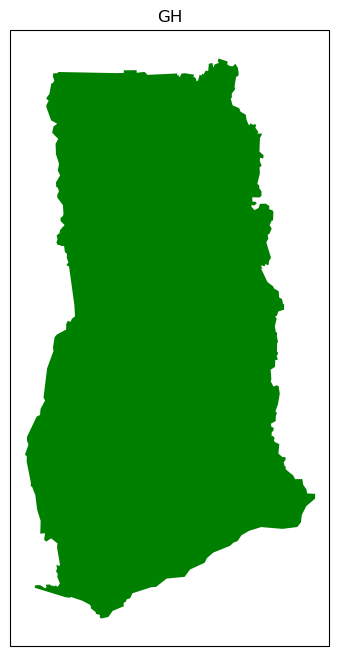

In [129]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

Component check

In [130]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 36 entries
Component 'Carrier' has 18 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 16 entries
Component 'LineType' has 34 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 48 entries
Component 'Load' has 12 entries
Component 'Generator' has 66 entries
Component 'StorageUnit' has 2 entries
Component 'Store' has 24 entries


Snapshot check

In [131]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 03:00:00',
               '2013-01-01 06:00:00', '2013-01-01 09:00:00',
               '2013-01-01 12:00:00', '2013-01-01 15:00:00',
               '2013-01-01 18:00:00', '2013-01-01 21:00:00',
               '2013-01-02 00:00:00', '2013-01-02 03:00:00',
               ...
               '2013-12-30 18:00:00', '2013-12-30 21:00:00',
               '2013-12-31 00:00:00', '2013-12-31 03:00:00',
               '2013-12-31 06:00:00', '2013-12-31 09:00:00',
               '2013-12-31 12:00:00', '2013-12-31 15:00:00',
               '2013-12-31 18:00:00', '2013-12-31 21:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=2920, freq=None)
Time steps: 2920


## Analyse energy system

Analyse the current capacity of the energy system - map view

/home/marco-s/miniconda3/envs/pypsa-earth-2/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


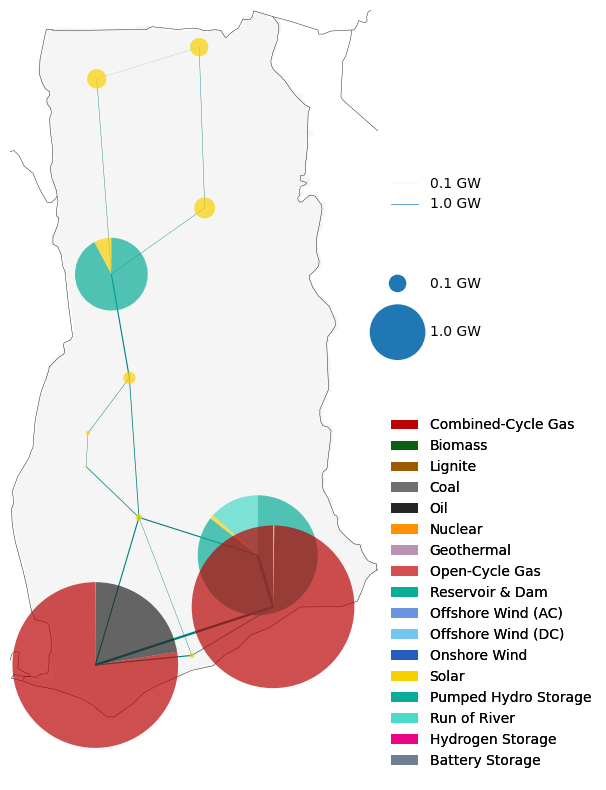

In [132]:
# Scale settings
bus_scale = 3e3 
line_scale = 2e3

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100, 1000]  # in MW

# n-noLoad = n.carriers.drop("Load", inplace=False)
n.carriers.drop("Load", inplace=True)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.1,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])

# Make more space at bottom to not cut off capacity circle
ylims = ax.get_ylim()  # Get current y-axis limits
ax.set_ylim(ylims[0] - 0.7e5, ylims[1])  # Extend the bottom by shifting downward

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()
fig.savefig("brownfield_capacities_" + scenario_name + ".png", bbox_inches="tight", dpi=300)

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier')

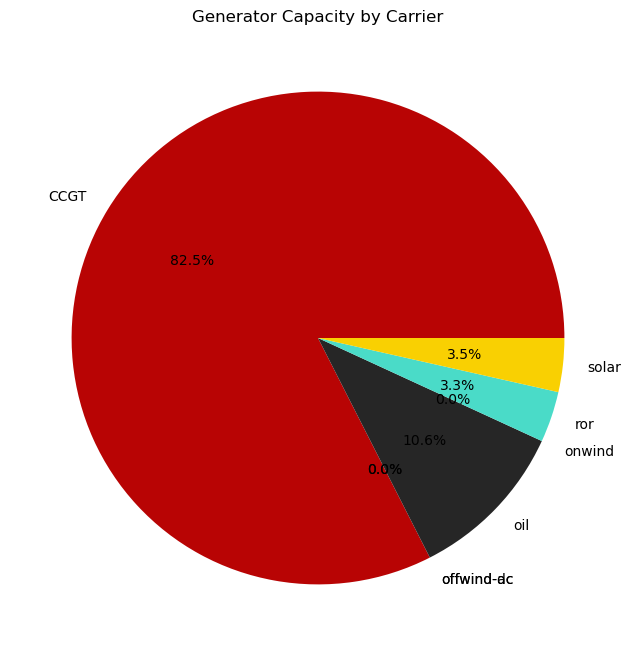

In [133]:
generator_capacity_by_carrier = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["carrier"]).p_nom.sum()
plt.figure(figsize=(8, 8))
plt.pie(generator_capacity_by_carrier, labels=generator_capacity_by_carrier.index, autopct='%1.1f%%', colors=n.carriers[n.carriers.index.isin(generator_capacity_by_carrier.index)].color.reindex(generator_capacity_by_carrier.index))
plt.title("Generator Capacity by Carrier")

Analyse the current gernation capacity of the energy system - tabular view

In [134]:
generator_capacity_by_carrier/1e3 # in GW

carrier
CCGT          3.952155
offwind-ac    0.000000
offwind-dc    0.000000
oil           0.509485
onwind        0.000000
ror           0.160000
solar         0.168954
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

/home/marco-s/miniconda3/envs/pypsa-earth-2/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


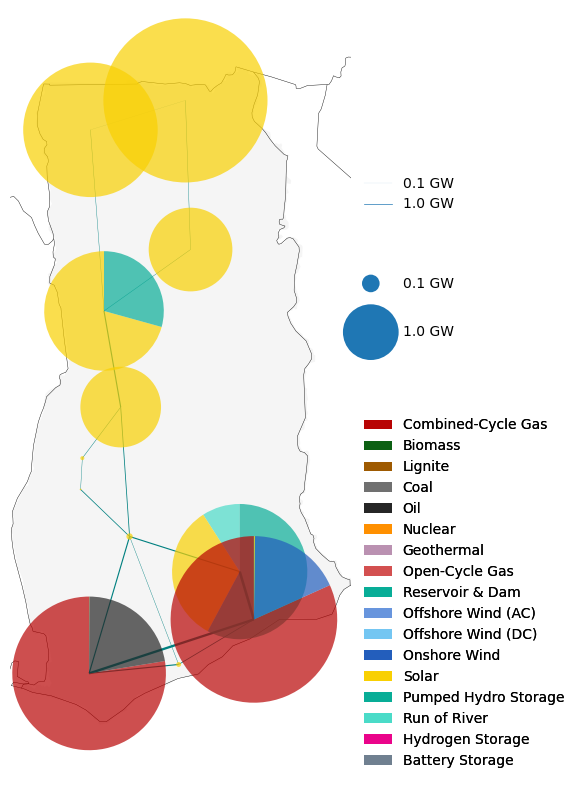

In [135]:
bus_scale = 3e3 
line_scale = 2e3

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])

# Make more space at bottom to not cut off capacity circle
ylims = ax.get_ylim()  # Get current y-axis limits
ax.set_ylim(ylims[0] - 0.7e5, ylims[1] + 0.7e5)  # Extend the bottom by shifting downward

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Calculate emissions of future energy system

In [136]:
#ToDo: Not fully correct - double check
co2_emissions = pd.DataFrame(data=n.carriers[["co2_emissions", "nice_name"]]).set_index("nice_name").squeeze().rename_axis("carrier")

energy_production = n.statistics.energy_balance().Generator.droplevel(1).drop(["load", "export"], errors="ignore")

co2_emissions_technology = energy_production * co2_emissions.loc[energy_production.index] * n.snapshot_weightings.generators[0]
co2_emissions_technology

/tmp/ipykernel_4952/272665663.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2_emissions_technology = energy_production * co2_emissions.loc[energy_production.index] * n.snapshot_weightings.generators[0]


carrier
Offshore Wind (DC)    0.0
Onshore Wind          0.0
Run of River          0.0
Solar                 0.0
dtype: float64

In [137]:
co2_emissions_sum = co2_emissions_technology.sum()
co2_emissions_sum

0.0

In [138]:
n.global_constraints

,sense,mu,type,investment_period,carrier_attribute,constant
GlobalConstraint,,,,,,
CO2Limit,<=,-8408.719893,primary_energy,NaN,co2_emissions,0.0


In [139]:
# Step 1: Create the links_energy DataFrame with "carrier" and "bus0" columns
links_energy = n.links[["carrier", "bus0"]]

# Step 2: Filter only rows where "carrier" contains 'export'
links_energy = links_energy[links_energy["carrier"].str.contains("export", case=False, na=False)]

# Step 3: Calculate the energy sum for indices that contain 'export'
export_energy = n.links_t.p0.sum()
export_energy = export_energy[export_energy.index.str.contains("export", case=False, na=False)]

# Step 4: Map the energy sum to the correct rows in links_energy based on the index
links_energy["energy"] = links_energy.index.map(export_energy)

# Step 5: Group by "bus0" and "carrier" and sum the "energy" values
links_energy_grouped = links_energy.groupby(["bus0", "carrier"], as_index=False)["energy"].sum()

# Display the result
links_energy_grouped


,bus0,carrier,energy


Analys the future generation capacity expansion of the energy system - bar chart

In [140]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion

carrier
Combined-Cycle Gas    0.00000
Offshore Wind (DC)        NaN
Oil                   0.00000
Onshore Wind              NaN
Run of River          0.00000
Solar                 7.04568
load                  0.00000
dtype: float64

Plot the future generation capacity expansion of the energy system - tabular chart

<AxesSubplot:title={'center':'Generator capacity expansion in GW'}, xlabel='carrier'>

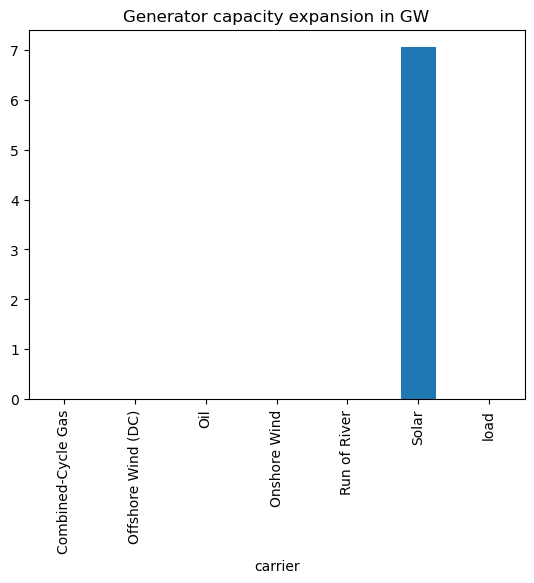

In [141]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Analyse the future energy generation of the energy system - bar chart view

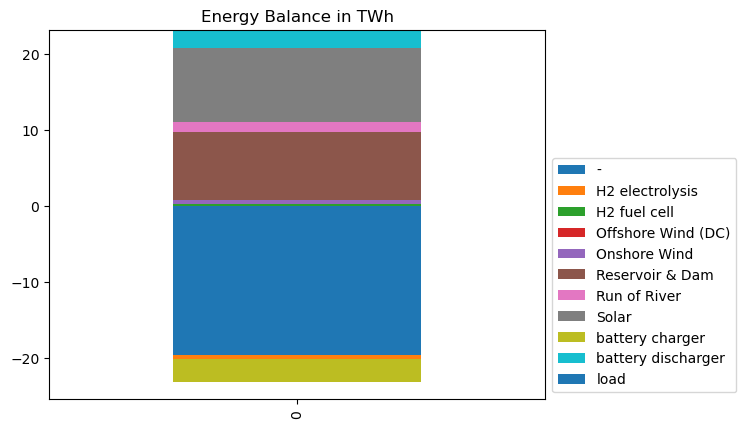

In [142]:
fig, ax = plt.subplots()
color_setting = n.carriers.set_index(n.carriers.nice_name)
energy_balance = n.statistics.energy_balance().loc[:, :, "AC"].groupby("carrier").sum().div(1e6).to_frame().T
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh")
n.carriers[n.carriers.index.isin(generator_capacity_by_carrier.index)].color.reindex(generator_capacity_by_carrier.index)

ax.legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

Analyse the future energy generation of the energy system - tabular view

In [143]:
n.statistics.energy_balance()/1e6 # In TWh

component    carrier             bus_carrier
StorageUnit  Reservoir & Dam     AC             8.876439e+00
Store        Battery Storage     battery       -8.640549e-17
             Hydrogen Storage    H2             1.125862e-16
Link         H2 electrolysis     AC            -5.792749e-01
             H2 fuel cell        H2            -4.634199e-01
             battery charger     AC            -2.968484e+00
             battery discharger  battery       -2.671636e+00
             H2 electrolysis     H2             4.634199e-01
             H2 fuel cell        AC             2.687835e-01
             battery charger     battery        2.671636e+00
             battery discharger  AC             2.404472e+00
Generator    Offshore Wind (DC)  AC             2.543981e-08
             Onshore Wind        AC             5.274242e-01
             Run of River        AC             1.401600e+00
             Solar               AC             9.723193e+00
             load                AC     

## Analyse pv and wind potential - map view

In [144]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    # br = gpd.read_file(f"resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br = gpd.read_file(PARENT + f"resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot pv energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


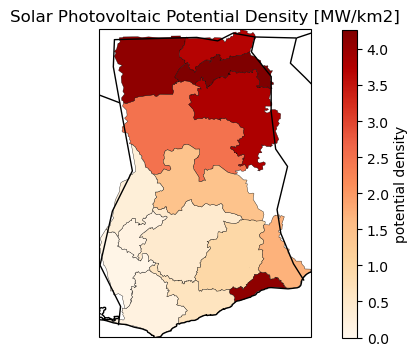

In [145]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot wind energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


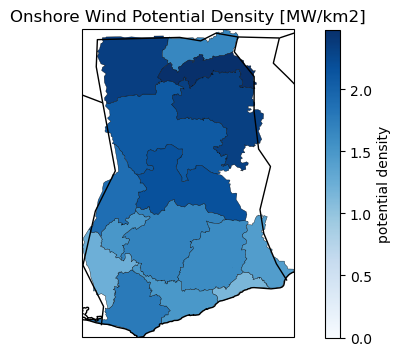

In [146]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Levelized cost of electricity

In [147]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity generation
# n.statistics.market_value() ?
lcoe = n.objective/n.statistics.energy_balance().Generator.sum()
lcoe 

56.27218081088785

In [148]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity demand
lcoe = n.objective/n.statistics.energy_balance().Load.sum()*(-1)
lcoe 

33.361686422535364

In [149]:
n.statistics.market_value()

component    carrier           
Generator    Offshore Wind (DC)    115.848403
             Onshore Wind          100.112573
             Run of River           81.252125
             Solar                  37.753041
             load                   74.191891
Line         AC                      0.673866
Link         H2 electrolysis        84.001204
             H2 fuel cell           46.745551
             battery charger        17.088811
             battery discharger      0.527968
Load         -                            NaN
StorageUnit  Reservoir & Dam       104.495000
Store        Battery Storage        49.884807
             Hydrogen Storage       26.259002
dtype: float64

Check storages

In [150]:
n.storage_units

,carrier,bus,p_nom,max_hours,p_min_pu,efficiency_dispatch,efficiency_store,cyclic_state_of_charge,control,marginal_cost,...,marginal_cost_quadratic,capital_cost,build_year,lifetime,state_of_charge_initial,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge_per_period,standing_loss,inflow
StorageUnit,,,,,,,,,,,,,,,,,,,,,
GH.11_2_AC hydro,hydro,GH.11_2_AC,404.0,39411.788515,0.0,0.9,0.0,True,,0.009920,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0
GH.6_2_AC hydro,hydro,GH.6_2_AC,1020.0,39411.788515,0.0,0.9,0.0,True,,0.010793,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0


## Additional input (Marco)

In [151]:
CCGT_col = [col for col in n.generators_t.p.columns if 'CCGT' in col]
n.generators_t.p[CCGT_col].sum()

Generator
GH.15_2_AC CCGT    0.0
GH.7_2_AC CCGT     0.0
dtype: float64

In [152]:
n.generators_t.p.columns

Index(['GH.11_2_AC H2 load', 'GH.11_2_AC battery load', 'GH.11_2_AC load',
       'GH.11_2_AC onwind', 'GH.11_2_AC solar', 'GH.12_2_AC H2 load',
       'GH.12_2_AC battery load', 'GH.12_2_AC load', 'GH.12_2_AC onwind',
       'GH.12_2_AC solar', 'GH.13_2_AC H2 load', 'GH.13_2_AC battery load',
       'GH.13_2_AC load', 'GH.13_2_AC onwind', 'GH.13_2_AC solar',
       'GH.15_2_AC CCGT', 'GH.15_2_AC H2 load', 'GH.15_2_AC battery load',
       'GH.15_2_AC load', 'GH.15_2_AC oil', 'GH.15_2_AC onwind',
       'GH.15_2_AC solar', 'GH.1_2_AC H2 load', 'GH.1_2_AC battery load',
       'GH.1_2_AC load', 'GH.1_2_AC onwind', 'GH.1_2_AC solar',
       'GH.2_2_AC H2 load', 'GH.2_2_AC battery load', 'GH.2_2_AC load',
       'GH.2_2_AC onwind', 'GH.2_2_AC solar', 'GH.3_2_AC H2 load',
       'GH.3_2_AC battery load', 'GH.3_2_AC load', 'GH.3_2_AC onwind',
       'GH.3_2_AC solar', 'GH.4_2_AC H2 load', 'GH.4_2_AC battery load',
       'GH.4_2_AC load', 'GH.4_2_AC onwind', 'GH.4_2_AC solar',
       'GH.5_

In [153]:
n.generators_t.p

Generator,GH.11_2_AC H2 load,GH.11_2_AC battery load,GH.11_2_AC load,GH.11_2_AC onwind,GH.11_2_AC solar,GH.12_2_AC H2 load,GH.12_2_AC battery load,GH.12_2_AC load,GH.12_2_AC onwind,GH.12_2_AC solar,...,GH.7_2_AC load,GH.7_2_AC offwind-ac,GH.7_2_AC offwind-dc,GH.7_2_AC onwind,GH.7_2_AC solar,GH.9_2_AC H2 load,GH.9_2_AC battery load,GH.9_2_AC load,GH.9_2_AC onwind,GH.9_2_AC solar
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,0.000004,0.000004,0.000004,2.404952e-05,0.000000,0.000004,0.000004,0.000004,0.000428,0.000000,...,0.000004,0.0,0.000000e+00,0.000000,0.000000,0.000004,0.000004,0.000004,0.000055,0.000000
2013-01-01 03:00:00,0.000004,0.000004,0.000004,2.162245e-05,0.000000,0.000004,0.000004,0.000004,0.000370,0.000000,...,0.000004,0.0,2.924052e-07,0.000000,0.000000,0.000004,0.000004,0.000004,0.000040,0.000000
2013-01-01 06:00:00,0.000004,0.000004,0.000004,1.597240e-05,45.784200,0.000004,0.000004,0.000004,0.000322,131.518970,...,0.000004,0.0,0.000000e+00,0.000000,0.316892,0.000004,0.000004,0.000004,0.000033,37.212877
2013-01-01 09:00:00,0.000004,0.000004,0.000004,1.106542e-05,420.071892,0.000004,0.000004,0.000004,0.000260,1139.115181,...,0.000004,0.0,0.000000e+00,29.853325,2.323105,0.000004,0.000004,0.000004,0.000028,296.478215
2013-01-01 12:00:00,0.000004,0.000004,0.000004,3.802927e-06,556.745422,0.000004,0.000004,0.000004,0.000065,1495.946242,...,0.000004,0.0,0.000000e+00,20.245328,3.019926,0.000004,0.000004,0.000004,0.000008,389.520318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-31 09:00:00,0.000004,0.000004,0.000004,0.000000e+00,400.753496,0.000004,0.000004,0.000004,0.000030,1090.855430,...,0.000004,0.0,5.466949e-06,52.800674,1.911894,0.000004,0.000004,0.000004,0.000000,285.060482
2013-12-31 12:00:00,0.000004,0.000004,0.000004,0.000000e+00,505.379500,0.000004,0.000004,0.000004,0.000022,1437.528624,...,0.000004,0.0,2.246626e-06,58.041508,2.376269,0.000004,0.000004,0.000004,0.000000,368.723153
2013-12-31 15:00:00,0.000004,0.000004,0.000004,0.000000e+00,286.122622,0.000004,0.000004,0.000004,0.000000,841.168361,...,0.000004,0.0,3.065686e-06,107.935752,1.249714,0.000004,0.000004,0.000004,0.000000,207.301532


In [154]:
import re

df = n.generators_t.p

# Extract the category (everything after "GH0 <number> ")
categories = [re.sub(r'GH0 \d+ ', '', col) for col in df.columns]

# Create a mapping from the original column names to their categories
column_mapping = dict(zip(df.columns, categories))

# Group by category
grouped = {}
for col, category in column_mapping.items():
    grouped.setdefault(category, []).append(col)

# Print grouped columns
for category, cols in grouped.items():
    print(f"{category}: {cols}")

print(grouped)

GH.11_2_AC H2 load: ['GH.11_2_AC H2 load']
GH.11_2_AC battery load: ['GH.11_2_AC battery load']
GH.11_2_AC load: ['GH.11_2_AC load']
GH.11_2_AC onwind: ['GH.11_2_AC onwind']
GH.11_2_AC solar: ['GH.11_2_AC solar']
GH.12_2_AC H2 load: ['GH.12_2_AC H2 load']
GH.12_2_AC battery load: ['GH.12_2_AC battery load']
GH.12_2_AC load: ['GH.12_2_AC load']
GH.12_2_AC onwind: ['GH.12_2_AC onwind']
GH.12_2_AC solar: ['GH.12_2_AC solar']
GH.13_2_AC H2 load: ['GH.13_2_AC H2 load']
GH.13_2_AC battery load: ['GH.13_2_AC battery load']
GH.13_2_AC load: ['GH.13_2_AC load']
GH.13_2_AC onwind: ['GH.13_2_AC onwind']
GH.13_2_AC solar: ['GH.13_2_AC solar']
GH.15_2_AC CCGT: ['GH.15_2_AC CCGT']
GH.15_2_AC H2 load: ['GH.15_2_AC H2 load']
GH.15_2_AC battery load: ['GH.15_2_AC battery load']
GH.15_2_AC load: ['GH.15_2_AC load']
GH.15_2_AC oil: ['GH.15_2_AC oil']
GH.15_2_AC onwind: ['GH.15_2_AC onwind']
GH.15_2_AC solar: ['GH.15_2_AC solar']
GH.1_2_AC H2 load: ['GH.1_2_AC H2 load']
GH.1_2_AC battery load: ['GH.1_2_AC

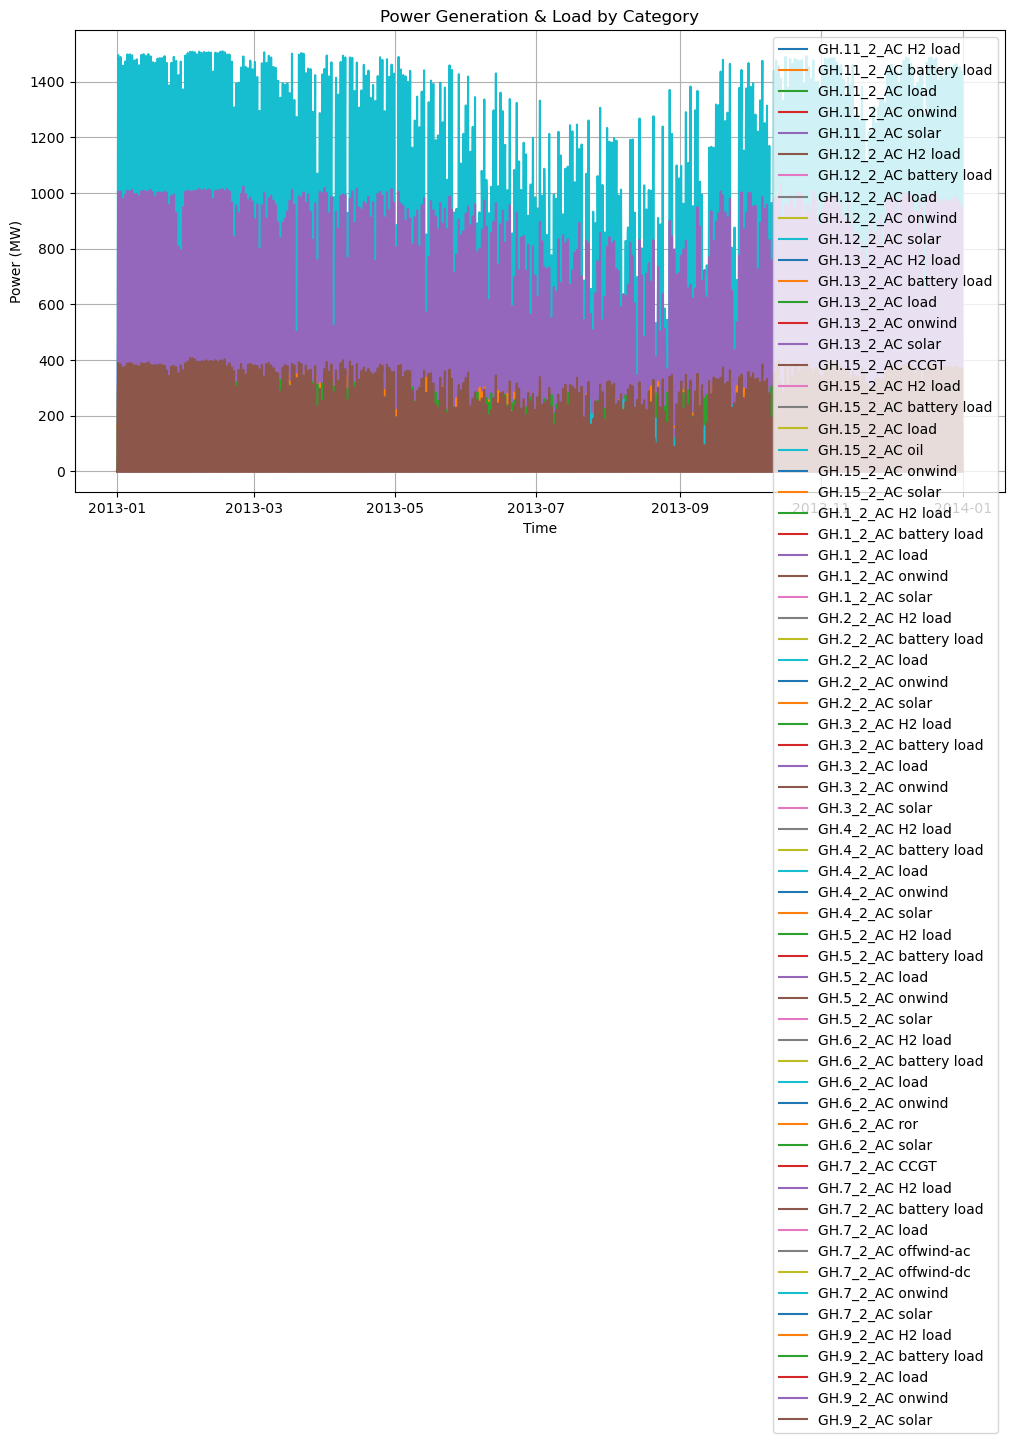

In [155]:
import pandas as pd
import re
import matplotlib.pyplot as plt


# Step 1: Extract category names
categories = [re.sub(r'GH0 \d+ ', '', col) for col in df.columns]

# Step 2: Create a mapping from category name to a list of columns
category_columns = {}
for col, category in zip(df.columns, categories):
    if category not in category_columns:
        category_columns[category] = []
    category_columns[category].append(col)

# Step 3: Sum data for each category and create a new DataFrame
grouped_data = pd.DataFrame({category: df[cols].sum(axis=1) for category, cols in category_columns.items()})

# Step 4: Plot the grouped time series
plt.figure(figsize=(12, 6))
for category in grouped_data.columns:
    plt.plot(grouped_data.index, grouped_data[category], label=category, linestyle="-")

# Formatting the plot
plt.xlabel("Time")
plt.ylabel("Power (MW)")  # Adjust based on your data units
plt.title("Power Generation & Load by Category")
plt.legend()
plt.grid(True)
plt.show()


Total load in 2013: 19.654152464746858 TWh


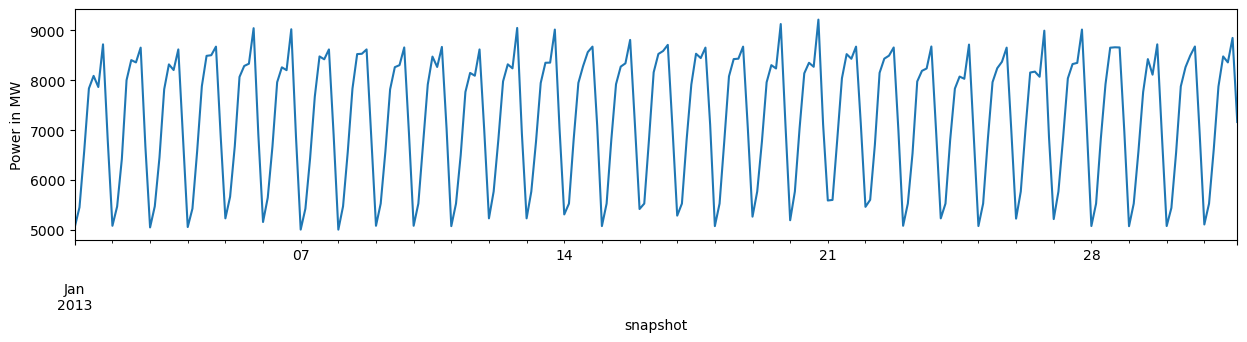

In [156]:
loads = n.loads_t.p.multiply(n.snapshot_weightings.generators, axis=0)
fig, ax = plt.subplots(figsize=(15, 3))
loads.sum(axis=1).loc['2013-01-01':'2013-01-31'].plot(ax=ax)
ax.set_ylabel('Power in MW')
print('Total load in 2013: {} TWh'.format(n.loads_t.p.multiply(n.snapshot_weightings.generators, axis=0).sum(axis=1).sum() / 1000000))

In [157]:
n.objective / 1e9 # billion europs p.a.
print("The total system cost is {:.0f} million euros per year".format(n.objective / 1e6))

The total system cost is 656 million euros per year


## Line expansion

<AxesSubplot:xlabel='Line'>

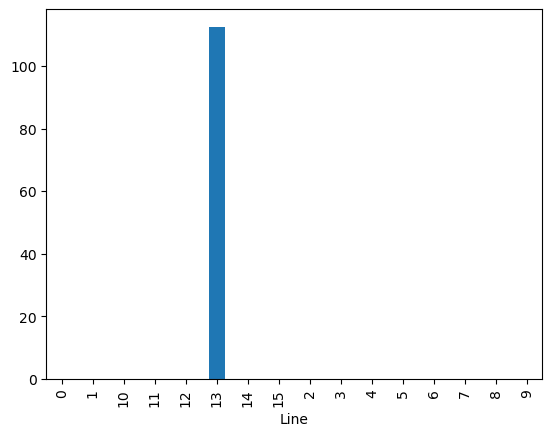

In [158]:
(n.lines.s_nom_opt - n.lines.s_nom).plot.bar()

Text(0, 0.5, 'Capacity in GW')

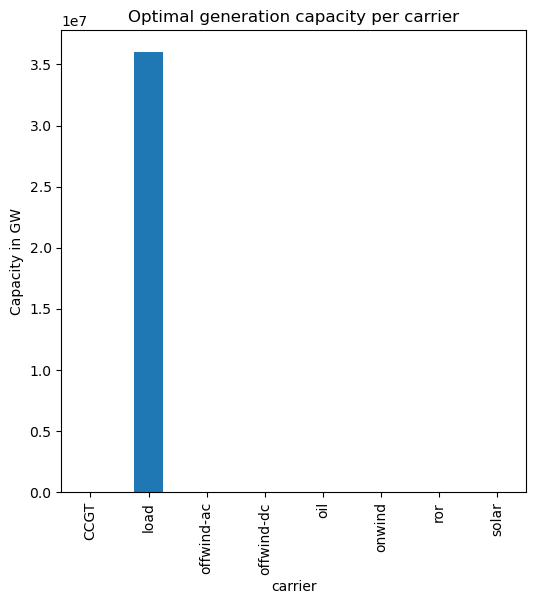

In [159]:
fig, ax = plt.subplots(figsize=(6,6))
n.generators.groupby('carrier').p_nom_opt.sum().multiply(1e-3).plot.bar(ax = ax)
ax.set_title('Optimal generation capacity per carrier')
ax.set_ylabel('Capacity in GW')

In [160]:
# n.generators.drop(n.generators[n.generators['carrier'] == 'load'], inplace=True)
n.generators = n.generators[n.generators['carrier'] != 'load']

In [161]:
n.storage_units.groupby('carrier').p_nom_opt.sum() / 1e3 # GW

carrier
hydro    1.424
Name: p_nom_opt, dtype: float64

<AxesSubplot:xlabel='snapshot'>

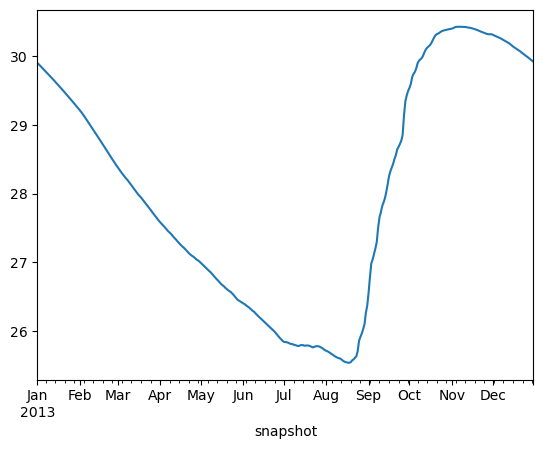

In [162]:
(n.storage_units_t.state_of_charge.sum(axis=1).resample('D').mean() / 1e6).plot()

In [163]:
n.storage_units_t.state_of_charge / 1e6

StorageUnit,GH.11_2_AC hydro,GH.6_2_AC hydro
snapshot,,
2013-01-01 00:00:00,8.377817,21.534221
2013-01-01 03:00:00,8.377097,21.531747
2013-01-01 06:00:00,8.376302,21.529265
2013-01-01 09:00:00,8.376428,21.528874
2013-01-01 12:00:00,8.376555,21.528602
...,...,...
2013-12-31 09:00:00,8.379985,21.542439
2013-12-31 12:00:00,8.380114,21.542632
2013-12-31 15:00:00,8.380243,21.541666


In [164]:
n.storage_units

,carrier,bus,p_nom,max_hours,p_min_pu,efficiency_dispatch,efficiency_store,cyclic_state_of_charge,control,marginal_cost,...,marginal_cost_quadratic,capital_cost,build_year,lifetime,state_of_charge_initial,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge_per_period,standing_loss,inflow
StorageUnit,,,,,,,,,,,,,,,,,,,,,
GH.11_2_AC hydro,hydro,GH.11_2_AC,404.0,39411.788515,0.0,0.9,0.0,True,,0.009920,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0
GH.6_2_AC hydro,hydro,GH.6_2_AC,1020.0,39411.788515,0.0,0.9,0.0,True,,0.010793,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0


In [165]:
n.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()

bus         carrier   
GH.11_2_AC  onwind           0.000105
            solar          974.514456
GH.12_2_AC  onwind           0.000976
            solar         2596.567628
GH.13_2_AC  onwind           0.000884
            solar         1743.470442
GH.15_2_AC  CCGT          1765.000000
            oil            509.484522
            onwind           0.000085
            solar            0.880201
GH.1_2_AC   onwind           0.000069
            solar            0.299724
GH.2_2_AC   onwind           0.000075
            solar            3.810672
GH.3_2_AC   onwind           0.000086
            solar            1.515767
GH.4_2_AC   onwind           0.000076
            solar          627.194712
GH.5_2_AC   onwind           0.000103
            solar            2.293610
GH.6_2_AC   onwind           0.000099
            ror            160.000000
            solar          583.278613
GH.7_2_AC   CCGT          2187.154566
            offwind-ac       0.000000
            offwind-dc     

Text(0.5, 1.0, 'State of charge in TWh')

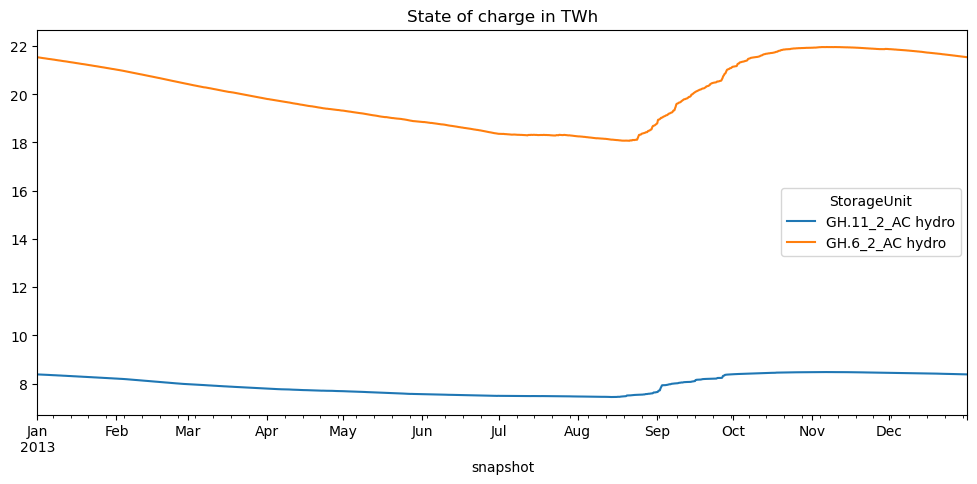

In [166]:
fig, ax = plt.subplots(figsize=(12,5))
(n.storage_units_t.state_of_charge / 1e6).plot(ax = ax)
ax.set_title('State of charge in TWh')

In [167]:
(n.storage_units_t.state_of_charge / 1e6)

StorageUnit,GH.11_2_AC hydro,GH.6_2_AC hydro
snapshot,,
2013-01-01 00:00:00,8.377817,21.534221
2013-01-01 03:00:00,8.377097,21.531747
2013-01-01 06:00:00,8.376302,21.529265
2013-01-01 09:00:00,8.376428,21.528874
2013-01-01 12:00:00,8.376555,21.528602
...,...,...
2013-12-31 09:00:00,8.379985,21.542439
2013-12-31 12:00:00,8.380114,21.542632
2013-12-31 15:00:00,8.380243,21.541666


<AxesSubplot:xlabel='snapshot'>

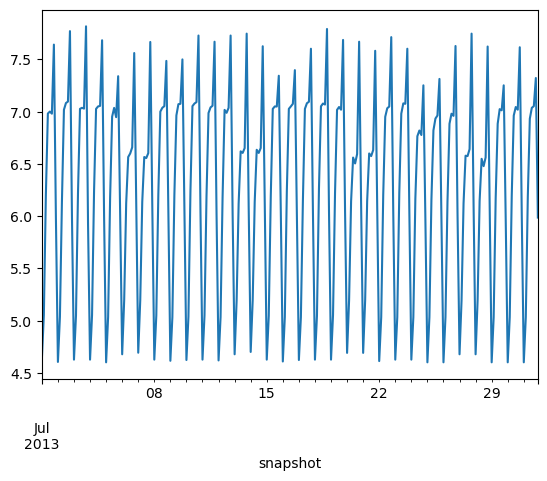

In [168]:
(n.loads_t.p.sum(axis=1).multiply(n.snapshot_weightings.generators) / 1e3).loc['2013-07'].plot()

<AxesSubplot:xlabel='snapshot'>

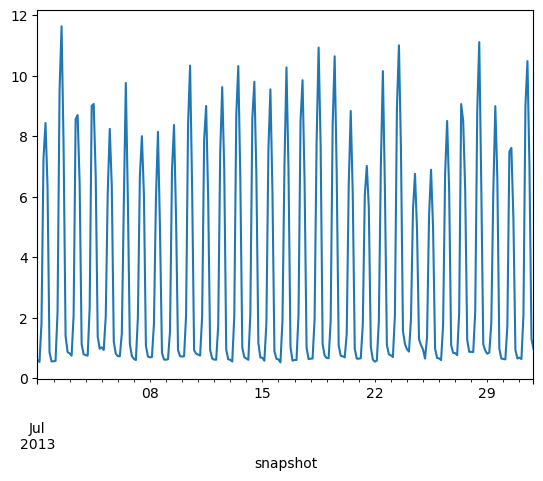

In [169]:
(n.generators_t.p.sum(axis=1).multiply(n.snapshot_weightings.generators) / 1e3).loc['2013-07'].plot()

In [170]:
gen_snap = n.generators_t.p.loc['2013-01-01 18:00:00']
gen_snap

Generator
GH.11_2_AC H2 load         0.000004
GH.11_2_AC battery load    0.000004
GH.11_2_AC load            0.000004
GH.11_2_AC onwind          0.000005
GH.11_2_AC solar           0.000000
                             ...   
GH.9_2_AC H2 load          0.000004
GH.9_2_AC battery load     0.000004
GH.9_2_AC load             0.000004
GH.9_2_AC onwind           0.000016
GH.9_2_AC solar            0.000000
Name: 2013-01-01 18:00:00, Length: 66, dtype: float64

<AxesSubplot:xlabel='snapshot'>

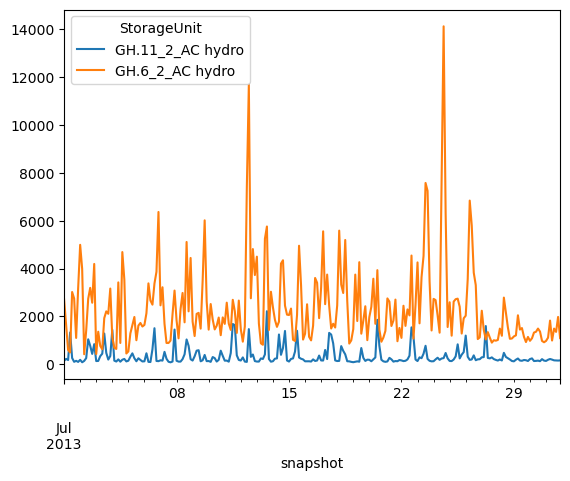

In [171]:
n.storage_units_t.inflow.multiply(n.snapshot_weightings.generators, axis=0).loc['2013-07'].plot()

In [172]:
n.statistics.capacity_factor(comps=["Generator", "StorageUnit"]).round(2)

component    carrier           
Generator    Offshore Wind (DC)    0.06
             Onshore Wind          0.12
             Run of River          1.00
             Solar                 0.15
StorageUnit  Reservoir & Dam       0.71
dtype: float64

In [173]:
n.statistics.supply().loc["StorageUnit"] / 1e6 # from MWh to TWh

carrier
Reservoir & Dam    8.876439
dtype: float64

In [174]:
n.statistics.dispatch(comps=["Generator", "StorageUnit"]).round(2) / 1e6

/tmp/ipykernel_4952/2211605357.py:1: DeprecatedWarning: dispatch is deprecated as of 0.28 and will be removed in 0.29. Use 'energy_balance' instead.
  n.statistics.dispatch(comps=["Generator", "StorageUnit"]).round(2) / 1e6


component    carrier           
Generator    Offshore Wind (DC)    3.000000e-08
             Onshore Wind          5.274242e-01
             Run of River          1.401600e+00
             Solar                 9.723193e+00
StorageUnit  Reservoir & Dam       8.876439e+00
dtype: float64

In [175]:
(n.storage_units_t.inflow.sum(axis=0) / 1e6 * 3).sum()# TWh

9.862710000000002

In [176]:
(n.storage_units_t.p.sum(axis=0) / 1e6 * 3).sum() # TWh

8.876438594016927

In [177]:
n.storage_units_t.spill.sum(axis=0) / 1e6

StorageUnit
GH.11_2_AC hydro    6.752643e-08
GH.6_2_AC hydro     8.284128e-08
dtype: float64

In [178]:
n.statistics.supply() / 1e6

component    carrier           
StorageUnit  Reservoir & Dam       8.876439e+00
Line         AC                    2.805947e+01
Store        Battery Storage       2.671627e+00
             Hydrogen Storage      4.634165e-01
Link         H2 electrolysis       4.634199e-01
             H2 fuel cell          2.687835e-01
             battery charger       2.671636e+00
             battery discharger    2.404472e+00
Generator    Offshore Wind (DC)    2.543981e-08
             Onshore Wind          5.274242e-01
             Run of River          1.401600e+00
             Solar                 9.723193e+00
dtype: float64

In [179]:
hydro_storage = n.storage_units["p_nom"] * n.storage_units["max_hours"] / 1e6 # TWh
print(hydro_storage)

StorageUnit
GH.11_2_AC hydro    15.922363
GH.6_2_AC hydro     40.200024
dtype: float64


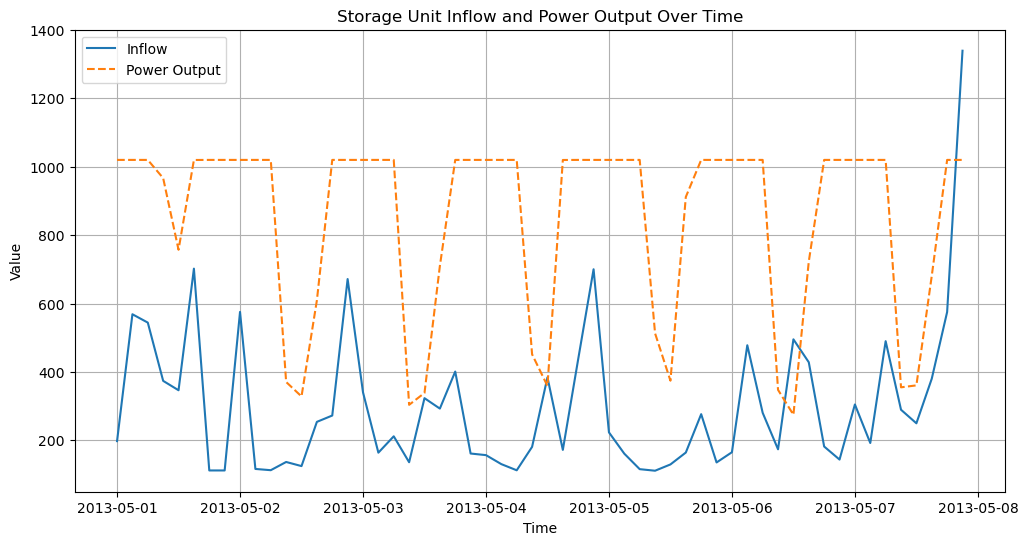

In [180]:
n.storage_units_t.inflow
type(n.storage_units_t.p)

# Assuming n.storage_units_t.inflow and n.storage_units_t.p are Pandas DataFrames
fig, ax = plt.subplots(figsize=(12, 6))

# Plot inflow
ax.plot(n.storage_units_t.inflow.loc["2013-5-01":"2013-5-07", 'GH.6_2_AC hydro'], label='Inflow', linestyle='-', marker='')

# Plot p
ax.plot(n.storage_units_t.p.loc["2013-5-01":"2013-5-07", 'GH.6_2_AC hydro'], label='Power Output', linestyle='--', marker='')

ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.set_title('Storage Unit Inflow and Power Output Over Time')
ax.legend()
ax.grid(True)

plt.show()

<AxesSubplot:xlabel='snapshot'>

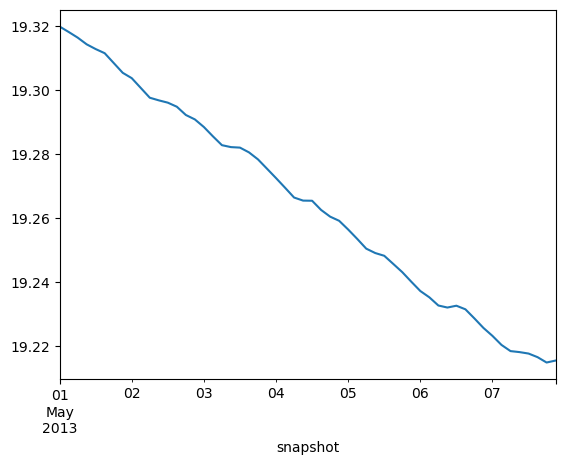

In [181]:
(n.storage_units_t.state_of_charge.loc["2013-5-01":"2013-5-07", 'GH.6_2_AC hydro'] / 1e6).plot()

In [182]:
n.storage_units.p_nom * n.storage_units.max_hours

StorageUnit
GH.11_2_AC hydro    1.592236e+07
GH.6_2_AC hydro     4.020002e+07
dtype: float64

In [183]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas       3952.154566         3952.154566   
            Offshore Wind (DC)          0.000045            0.000000   
            Oil                       509.484522          509.484522   
            Onshore Wind              482.985950            0.000000   
            Run of River              160.000000          160.000000   
            Solar                    7214.634358          168.954000   
Line        AC                      20391.462916        20278.920137   
Link        H2 electrolysis           797.673802            0.000000   
            H2 fuel cell              513.533778            0.000000   
            battery charger          1217.199032            0.000000   
            battery discharger       1352.443369            0.000000   
Load        -                           0.000000            0.000000   
StorageUnit Reservoir & Dam          1424.000000         1424.000000   
Store       Battery Storage          8393.666078            0.000000   
            Hydrogen Storage        15282.101630            0.000000   

                                      Supply    Withdrawal      Dispatch  \
Generator   Combined-Cycle Gas  0.000000e+00  0.000000e+00  0.000000e+00   
            Offshore Wind (DC)  2.543981e-02  0.000000e+00  2.543981e-02   
            Oil                 0.000000e+00  0.000000e+00  0.000000e+00   
            Onshore Wind        5.274242e+05  0.000000e+00  5.274242e+05   
            Run of River        1.401600e+06  0.000000e+00  1.401600e+06   
            Solar               9.723193e+06  0.000000e+00  9.723193e+06   
Line        AC                  2.805947e+07  2.805947e+07  0.000000e+00   
Link        H2 electrolysis     4.634199e+05  5.792749e+05 -1.158550e+05   
            H2 fuel cell        2.687835e+05  4.634199e+05 -1.946364e+05   
            battery charger     2.671636e+06  2.968484e+06 -2.968484e+05   
            battery discharger  2.404472e+06  2.671636e+06 -2.671636e+05   
Load        -                   0.000000e+00  1.965415e+07 -1.965415e+07   
StorageUnit Reservoir & Dam     8.876439e+06  0.000000e+00  8.876439e+06   
Store       Battery Storage     2.671627e+06  2.671627e+06 -8.640549e-11   
            Hydrogen Storage    4.634165e+05  4.634165e+05  1.125862e-10   

                                Transmission  Capacity Factor  Curtailment  \
Generator   Combined-Cycle Gas      0.000000         0.000000     0.000000   
            Offshore Wind (DC)      0.000000         0.064694     0.018876   
            Oil                     0.000000         0.000000     0.000000   
            Onshore Wind            0.000000         0.124658     0.478328   
            Run of River            0.000000         1.000000     0.000000   
            Solar                   0.000000         0.153848  8918.011811   
Line        AC                  70871.730904         0.157082     0.000000   
Link        H2 electrolysis         0.000000         0.082900     0.000000   
            H2 fuel cell            0.000000         0.103015     0.000000   
            battery charger         0.000000         0.278400     0.000000   
            battery discharger      0.000000         0.225504     0.000000   
Load        -                       0.000000              NaN     0.000000   
StorageUnit Reservoir & Dam         0.000000         0.711582     0.000000   
Store       Battery Storage         0.000000         0.436041     0.000000   
            Hydrogen Storage        0.000000         0.444808     0.000000   

                                Capital Expenditure  Operational Expenditure  \
Generator   Combined-Cycle Gas         3.338350e+08             0.000000e+00   
            Offshore Wind (DC)         1.130269e+01             6.133517e-04   
            Oil                        1.947992e+07             0.000000e+00   
            Onshore Wind               5.278822e+07             1.364287e+04   
            R